# K-Means Clustering

This technique is an unsupervised learning, wich allows for the discovery of hidden structures in the data where it is quite possible the answer may or may not be known.  The goal of clustering is the find the natural grouping in datasets so that items in the same cluster are more similar to each other than those of different clusters.

This analysis can be viewed as exploratory, thus can be an exciting topic of study.  This guide will show the following:

- use k-mean algorithm
- the elbow method for estimate k

This analysis will be done leveraging scikit-learn and the Spatial DataFrame.

## Grouping Objects Using Similarity

One of the most popular clustering algorithms is k-means.  It is widely used in both academic and industrial settings.  Clustering is a technique that allows for the discovery of finding groups of similar objects.  

#### Example Applications

    - grouping of documents by topic
    - gouping of music by genre 
    - finding customers that have similar interests

## Using scikit-learn K-means Algorithm

To implement the k-means algorithm in scikit-learn is simple and has the property of also being very memory efficient.  The k-means algorithm is prototype-based clustering.  This means that each cluster is represented by a *prototype* which can be a **centroid** of all similar points or the most representative occuring points (**medoid**). 

When it comes to the shape of the cluster, k-means is good at identifying spherical shapes. The drawback to using this methods is that you need to specify a **k** or **a priori**.  This means that a poor choice of **k** the cluster will be poor.

#### Simple Example of K-Means

Let's take 150 sample points and plot the points and plot it.

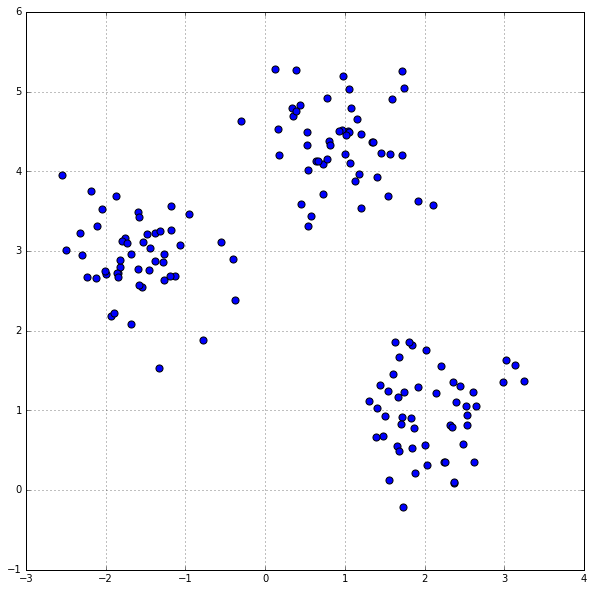

In [61]:
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt
x,y = make_blobs(n_samples=150,
                n_features=2,
                centers=3,
                shuffle=True,
                 random_state=0,
                cluster_std=.5)
plt.figure(figsize=(10,10))
plt.scatter(x[:,0], x[:,1], c='blue', marker='o', edgecolor='black', s=50)
plt.grid()
plt.show()

In the real world, there is no ground truth of category information about the samples.  Thus, the goal is to group the samples based on feature similarities, which is achieved using the k-means algorithim.  The algorithm can be summarized by the following steps:

1. Randomly pick **k** centroids from the samples points as initial centers of the clusters.
2. Assign each sample to the nearest centroid.
3. Move the centroids to the center of the samples that were assigned to it
4. Repeat steps 2 and 3 until the cluster assignments do not change, a user-defined tolerance, or a manimum number of iteration is reached.

#### How to Measure Simiarity between Objects?


In this case, similarity measure is the **Squared Euclidean Distance** between two points **x** and **y** in m-dimensional space.


<center>$d(x,y)^2 = \sum_{j=1}^{m}(x_j-y_i)^2 = \|x - y\|^2_2$</center>

Using the euclidean distance metric above, the k-means algorithm can be described as an optimization problem, an iterative approach to minimize the within-cluster **Sum of Squared Errors (SSE)** or **cluster interia**.

<center>$SSE = \sum_{i=1}^{n} \sum_{j=1}^{k}w^{(i,j)} \|x^i - \mu^j\|^2_2$</center>

Here $\mu^j$ is the centroid of the cluster *j* and $w^{(i,j)} = 1$ if the sample $x^i$ is in the cluster $j$, else the $w^{(i,j)} = 0$.


In [26]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3,
           init='random',
           n_init=10,
           max_iter=300,
           tol=0.0001,
           random_state=0)
y_km = km.fit_predict(x)

The code above did the following:

- Set the number of clusters to 3 (this is the *a priori* limitation)
- The n_imit=10 means that the k-means cluster will be run 10 times independantly with different random centroids. The model with the lowest **SSE** is returned.
- max_iter specifies the number of times k-means is run in a single instance.

A problem with k-means is that one of more clusters can be empty, but scikit-learn has ensured that this will not happen because the algorithm will search for the sample that is farthest away from the centroid of the empty cluster and reassign the centoid to be that farthest point.

#### Displaying the Cluster Group Names:

In [27]:
set(y_km)

{0, 1, 2}

#### Visualizing K-Means Results

Using the simple sample from above the data can be simply plotted usinng matplotlib.

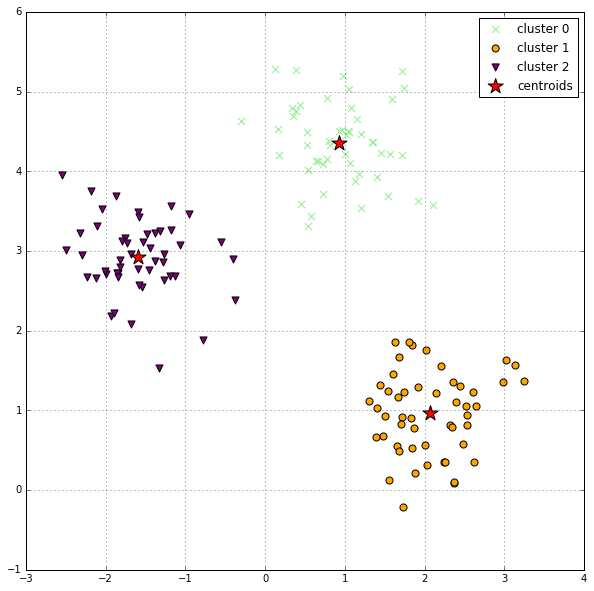

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
colors = ['lightgreen', 'orange', 'purple']
markers = ['x', 'o', 'v']
clusters = list(set(y_km))
for idx in range(len(clusters)):
    plt.scatter(
        x[y_km==clusters[idx], 0], 
        x[y_km==clusters[idx], 1],
        s=50,
        c=colors[idx],
        marker=markers[idx],
        edgecolor='black',
        label="cluster %s" % idx)
plt.scatter(km.cluster_centers_[:,0],
            km.cluster_centers_[:,1],
            s=250,
            marker='*',
            c='red',
            edgecolor='black',
            label='centroids'
           )

plt.legend(scatterpoints=1)
plt.grid()
plt.show()

## Performing K-Means++

Discussed we have looked at the classic k-means algorithm that uses a random seed to place the initial centroids.  This can sometimes result in bad cluster or slow convergences of the initial centroids.  To address this issue is to run the k-means algorithm multiple times on a dataset and choose the best performing model in terms of the SSE.

A better strategy is to place the inital centroids far awar from each other using the k-means++ algorithm.  This can lead to better and consistent results than classic k-means.

To do this with scikit-learn, change *KMean* object and set the *init* parameter to **k-means++** instead of **random**.

In [34]:
km = KMeans(n_clusters=3,
           init='k-means++',
           n_init=10,
           max_iter=300,
           tol=0.0001,
           random_state=0)
y_km = km.fit_predict(x)

If you plot the data, it will look similar due to the nature of the sample points.

### Finding the Optimal Number of Clusters

The elbow method to estimate the optimal number of **k** clusters for a given task.  We can say that if k increases, the distortion will decrease.  This is because the samples will be closer to the centroids they are associated with.  The point of the method is to identify the value of **k** where the distortion begins to increase the most rapidly.



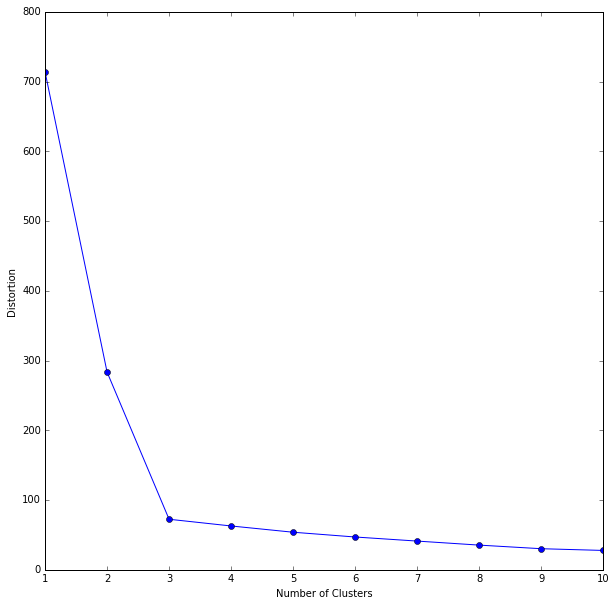

In [40]:
import matplotlib.pyplot as plt
distortions = []
for i in range(1,11):
    km = KMeans(n_clusters=i,
           init='k-means++',
           n_init=10,
           max_iter=300,
           random_state=0)
    km.fit(x)
    distortions.append(km.inertia_)
plt.figure(figsize=(10,10))
plt.plot(range(1,11), distortions, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Distortion')
plt.show()

The graph shows that the *elbow* is located at $k=3$, so we should use 3 for the number of clusters.

### Performing K-Means Analysis on a Service

This same analysis can be applied to spatial, and the Python API allows for the easy access of both local and service data.  In this example we will use a Feature Layer and extract data to a spatial dataframe.  After the data is loaded into the dataframe, a simple data transformation will be performed to get the X/Y coordinates into a format usable for scikit-learn.

In [41]:
from arcgis.gis import GIS
gis = GIS()
crime_data = gis.content.search("id: d926c91595824609a4ac87bd22298b1c",item_type="Feature Layer Collection")[0]
crime_data                                

<Item title:"Crime" type:Feature Layer Collection owner:kevi5986@esri.com_DBSNE>

Pull the data into a Spatial DataFrame.

In [44]:
query = "NEIGHBORHOOD_ID in ('university-hills', 'cheesman-park', 'washington-park')"
sdf = crime_data.layers[0].query(query).df

Transform the 'SHAPE' column into X/Y coordinates.

In [45]:
sdf['X'] = sdf.SHAPE.apply(lambda x: x.x)
sdf['Y'] = sdf.SHAPE.apply(lambda x: x.y)
sdf['XY'] = sdf.SHAPE.apply(lambda x: [x.x, x.y])

View the top 5 records in order to ensure the data is an acceptable format.

In [47]:
sdf.head()

,DISTRICT_ID,FID,FIRST_OCCURRENCE_DATE,GEO_LAT,GEO_LON,GEO_X,GEO_Y,INCIDENT_ADDRESS,INCIDENT_ID,IS_CRIME,...,OFFENSE_CODE,OFFENSE_CODE_EXTENSION,OFFENSE_ID,OFFENSE_TYPE_ID,PRECINCT_ID,REPORTED_DATE,SHAPE,X,Y,XY
0,3,3,1352896499000,39.680086,-104.936603,3158574,1673092,2000 S COLORADO BLVD,2012530922,1,...,2404,0,2.012531e+15,theft-of-motor-vehicle,313,1352923259000,"{'spatialReference': {'latestWkid': 3857, 'wki...",-1.168149e+07,4.819562e+06,"[-11681489.222667852, 4819561.617354572]"
1,6,7,1352910600000,39.739993,-104.962240,3151229,1694870,E COLFAX AVE / N VINE ST,2012530999,1,...,1315,2,2.012531e+15,menacing-felony-w-weap,622,1352981699000,"{'spatialReference': {'latestWkid': 3857, 'wki...",-1.168434e+07,4.828230e+06,"[-11684343.164981116, 4828230.468398412]"
2,3,9,1328746559000,39.714729,-104.973148,3148215,1685649,S DOWNING ST / E BAYAUD AVE,201253108,0,...,5420,0,2.012531e+14,traffic-accident-dui-duid,312,1328748300000,"{'spatialReference': {'latestWkid': 3857, 'wki...",-1.168556e+07,4.824574e+06,"[-11685557.382326944, 4824573.601636781]"
3,3,25,1371146400000,39.666689,-104.937254,3158421,1668211,2750 S COLORADO BLVD,2013267532,1,...,2303,0,2.013268e+15,theft-shoplift,313,1371148259000,"{'spatialReference': {'latestWkid': 3857, 'wki...",-1.168156e+07,4.817624e+06,"[-11681561.69165636, 4817624.052674899]"
4,3,101,1374058800000,39.653492,-104.927504,3161196,1663421,3485 S FOREST ST,2013331597,1,...,1316,0,2.013332e+15,threats-to-injure,313,1374095040000,"{'spatialReference': {'latestWkid': 3857, 'wki...",-1.168048e+07,4.815716e+06,"[-11680476.337753074, 4815715.72300065]"


Use the **KMeans++** algorithm on the Spatial DataFrame data with a **n_cluster = 5**.

In [72]:
km = KMeans(n_clusters=5,
           init='k-means++',
           n_init=10,
           max_iter=300,
           tol=0.0001,
           random_state=0)
x = np.array(sdf['XY'].tolist())
y_km = km.fit_predict(x)

To get a sense of how the algorithm did, plot the results quickly.

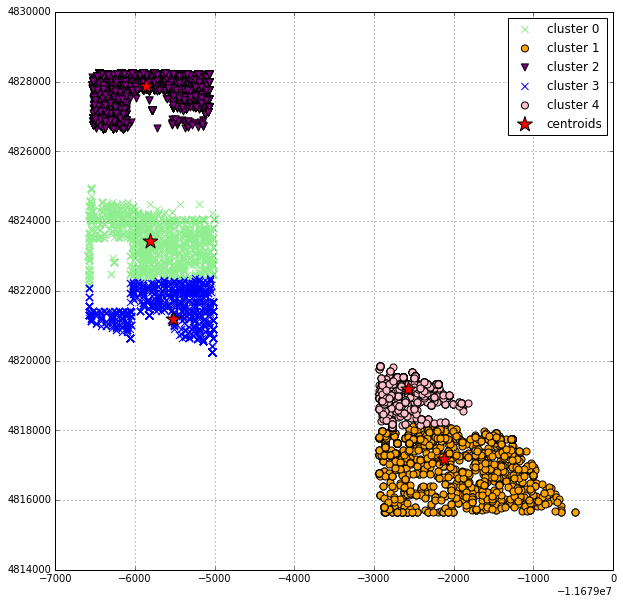

In [74]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
colors = ['lightgreen', 'orange', 'purple', 'blue', 'pink']
markers = ['x', 'o', 'v', 'x', 'o']
clusters = list(set(y_km))
for idx in range(len(clusters)):
    plt.scatter(
        x[y_km==clusters[idx], 0], 
        x[y_km==clusters[idx], 1],
        s=50,
        c=colors[idx],
        marker=markers[idx],
        edgecolor='black',
        label="cluster %s" % idx)
plt.scatter(km.cluster_centers_[:,0],
            km.cluster_centers_[:,1],
            s=250,
            marker='*',
            c='red',
            edgecolor='black',
            label='centroids'
           )

plt.legend(scatterpoints=1)
plt.grid()
plt.show()

The next step is to see how well our cluster size is by perform the elbow method.

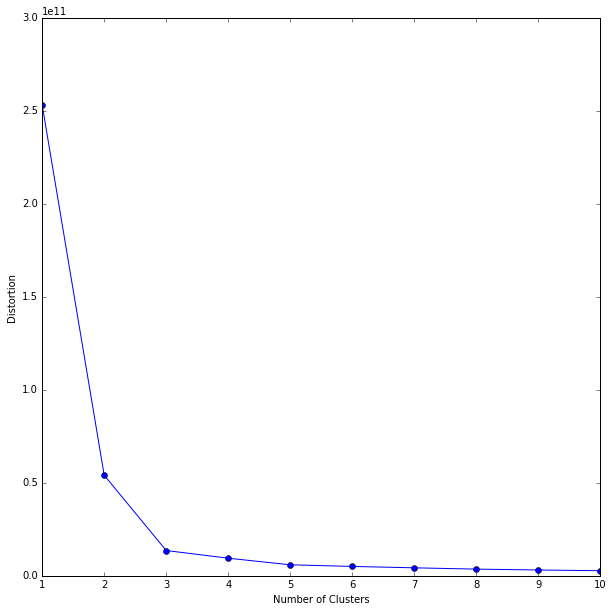

In [75]:
import matplotlib.pyplot as plt
distortions = []
for i in range(1,11):
    km =  KMeans(n_clusters=i,
           init='k-means++',
           n_init=10,
           max_iter=300,
           tol=0.0001,
           random_state=0)
    km.fit(x)
    distortions.append(km.inertia_)
plt.figure(figsize=(10,10))
plt.plot(range(1,11), distortions, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Distortion')
plt.show()

For this example, a **k** of 3 would be better.  This makes sense because the query used was on 3 distinct areas.

#### Relate the Cluster Values Back to the Spatial DataFrame

Now that we have the best **k** size of 3, we can add that properties back to the Spatial DataFrame. As expected, we should have 3 labels and each label index relates back to an index on the dataframe.

In [80]:
import pandas as pd
km =  KMeans(n_clusters=3,
            init='k-means++',
            n_init=10,
            max_iter=300,
            tol=0.0001,
            random_state=0)
y_km = km.fit_predict(x)

{0, 1, 2}

In [82]:
df = pd.DataFrame(y_km, columns=['CLUSTER_ID'])
df.head()

,CLUSTER_ID
0,1
1,2
2,0
3,1
4,1


Join the Spatial DataFrame and DataFrame on the Index

In [91]:
sdf = sdf.join(other=df)
sdf.head()

,DISTRICT_ID,FID,FIRST_OCCURRENCE_DATE,GEO_LAT,GEO_LON,GEO_X,GEO_Y,INCIDENT_ADDRESS,INCIDENT_ID,IS_CRIME,...,OFFENSE_CODE_EXTENSION,OFFENSE_ID,OFFENSE_TYPE_ID,PRECINCT_ID,REPORTED_DATE,SHAPE,X,Y,XY,CLUSTER_ID
0,3,3,1352896499000,39.680086,-104.936603,3158574,1673092,2000 S COLORADO BLVD,2012530922,1,...,0,2.012531e+15,theft-of-motor-vehicle,313,1352923259000,"{'spatialReference': {'latestWkid': 3857, 'wki...",-1.168149e+07,4.819562e+06,"[-11681489.222667852, 4819561.617354572]",1
1,6,7,1352910600000,39.739993,-104.962240,3151229,1694870,E COLFAX AVE / N VINE ST,2012530999,1,...,2,2.012531e+15,menacing-felony-w-weap,622,1352981699000,"{'spatialReference': {'latestWkid': 3857, 'wki...",-1.168434e+07,4.828230e+06,"[-11684343.164981116, 4828230.468398412]",2
2,3,9,1328746559000,39.714729,-104.973148,3148215,1685649,S DOWNING ST / E BAYAUD AVE,201253108,0,...,0,2.012531e+14,traffic-accident-dui-duid,312,1328748300000,"{'spatialReference': {'latestWkid': 3857, 'wki...",-1.168556e+07,4.824574e+06,"[-11685557.382326944, 4824573.601636781]",0
3,3,25,1371146400000,39.666689,-104.937254,3158421,1668211,2750 S COLORADO BLVD,2013267532,1,...,0,2.013268e+15,theft-shoplift,313,1371148259000,"{'spatialReference': {'latestWkid': 3857, 'wki...",-1.168156e+07,4.817624e+06,"[-11681561.69165636, 4817624.052674899]",1
4,3,101,1374058800000,39.653492,-104.927504,3161196,1663421,3485 S FOREST ST,2013331597,1,...,0,2.013332e+15,threats-to-injure,313,1374095040000,"{'spatialReference': {'latestWkid': 3857, 'wki...",-1.168048e+07,4.815716e+06,"[-11680476.337753074, 4815715.72300065]",1


The data is not ready for further analysis or display.  This means a user can import it to portal, AGOL or save it to a local dataset.